Question 1

In [3]:
import pandas as pd

# File path
file_path = r"C:\Users\HP\Desktop\Sales Analysis\Data\3. Sample Sales Data.xlsx"

# Read all sheets
excel_file = pd.ExcelFile(file_path)

# Store all sheet dataframes
all_data = []

for sheet in excel_file.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    all_data.append(df)

# Combine all sheets
combined_df = pd.concat(all_data, ignore_index=True)

# Remove rows where Revenue is missing or zero
cleaned_df = combined_df.dropna(subset=['Revenue'])
cleaned_df = cleaned_df[cleaned_df['Revenue'] != 0]

# Convert Date column to datetime
cleaned_df['Date'] = pd.to_datetime(cleaned_df['Date'])

# Filter records for year 2023
data_2023 = cleaned_df[cleaned_df['Date'].dt.year == 2023]

# Number of records
print("Number of records for 2023:", len(data_2023))

# Save cleaned dataset
cleaned_df.to_csv(r"C:\Users\HP\Desktop\Sales Analysis\Output\cleaned_sales_data.csv", index=False)

Number of records for 2023: 906


Question 2

In [5]:
# Total revenue by region
region_revenue = (
    cleaned_df.groupby('Region')['Revenue']
    .sum()
    .reset_index()
)

# Sort descending
region_revenue = region_revenue.sort_values(
    by='Revenue',
    ascending=False
)

print(region_revenue)

# Average units sold by product
avg_units = (
    cleaned_df.groupby('Product')['Units_Sold']
    .mean()
    .reset_index()
)

print(avg_units)

  Region    Revenue
0   East  224901.65
3   West  222707.49
1  North  210449.53
2  South  209615.34
      Product  Units_Sold
0     Almonds   24.582090
1     Cashews   24.777580
2  Pistachios   25.386874
3     Raisins   24.858238
4     Walnuts   26.853432


Question 3

In [6]:
# Create Month column
cleaned_df['Month'] = cleaned_df['Date'].dt.strftime('%Y-%m')

# Pivot table
pivot_table = pd.pivot_table(
    cleaned_df,
    values='Revenue',
    index='Product',
    columns='Month',
    aggfunc='sum',
    fill_value=0
)

print(pivot_table)

# Save pivot table
pivot_table.to_csv(r"C:\Users\HP\Desktop\Sales Analysis\Output\revenue_pivot_table.csv")

# Top 10 products per month
top_products = (
    cleaned_df.groupby(['Month', 'Product'])['Revenue']
    .sum()
    .reset_index()
)

top_10_per_month = (
    top_products.sort_values(
        ['Month', 'Revenue'],
        ascending=[True, False]
    )
    .groupby('Month')
    .head(10)
)

print(top_10_per_month)

Month       2022-01  2022-02  2022-03  2022-04  2022-05  2022-06  2022-07  \
Product                                                                     
Almonds     4682.22  5275.02  4120.66  3219.09  4808.65  3447.69  7266.97   
Cashews     6743.63  2997.57  4913.71  3885.68  5239.07  5133.42  7193.80   
Pistachios  4461.96  2508.47  4582.77  5765.70  7151.51  8886.13  2496.03   
Raisins     2426.35  3119.55  4401.20  6401.90  4683.20  4105.19  4377.96   
Walnuts     5821.50  4954.70  4671.54  4937.08  6782.94  4719.90  5013.94   

Month       2022-08  2022-09  2022-10  ...  2024-03  2024-04  2024-05  \
Product                                ...                              
Almonds     5217.93  3755.19  3196.44  ...  6345.07  4630.73  4239.87   
Cashews     6094.75  4144.83  5056.94  ...  6317.00  3851.70  5783.79   
Pistachios  7955.43  5200.69  9506.06  ...  2088.43  3920.28  5102.24   
Raisins     6075.71  4753.19  5198.72  ...  4608.46  5809.30  4830.81   
Walnuts     3076.87  5

Question 4

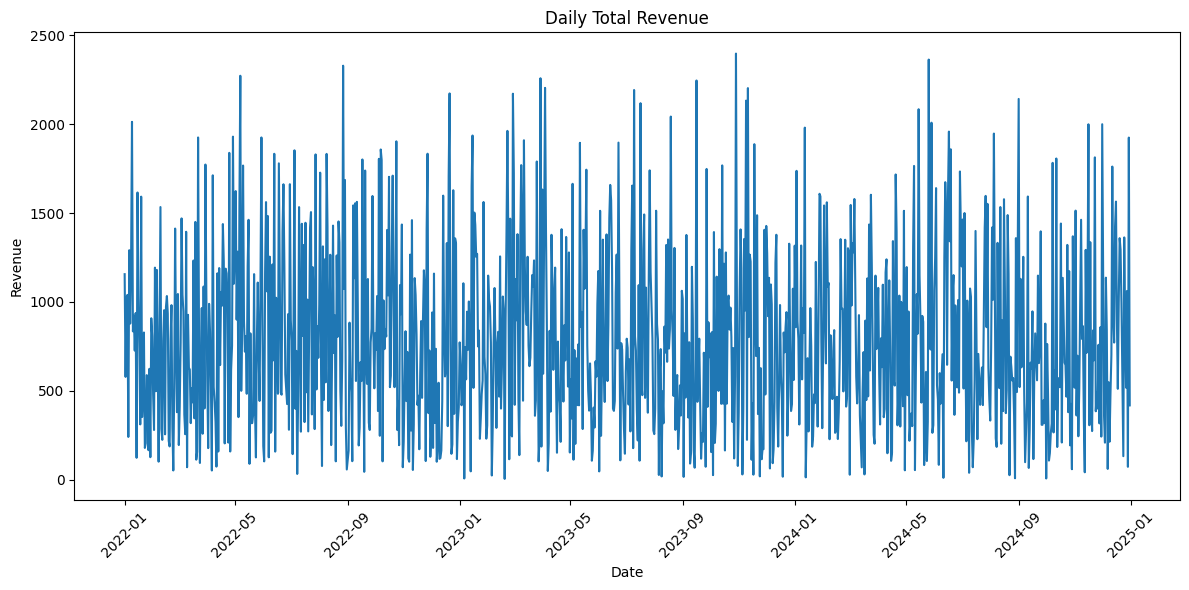

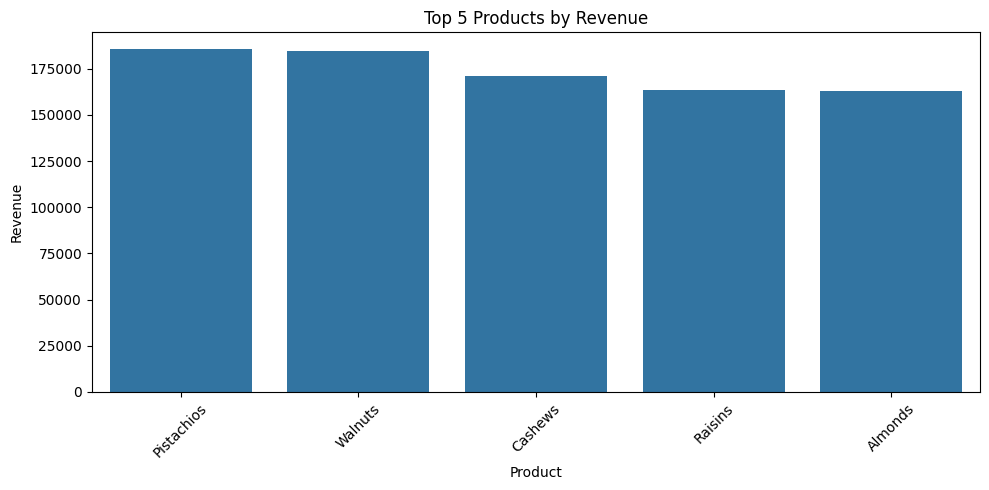

In [10]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create output folder if it doesn't exist
os.makedirs("Output", exist_ok=True)


# Daily Revenue Line Chart


daily_revenue = (
    cleaned_df.groupby('Date')['Revenue']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=daily_revenue,
    x='Date',
    y='Revenue'
)

plt.title("Daily Total Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()

# Save chart
plt.savefig(
    r"C:\Users\HP\Desktop\Sales Analysis\Output\daily_total_revenue.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# Top 5 Products Bar Chart


top_5_products = (
    cleaned_df.groupby('Product')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_5_products.index,
    y=top_5_products.values
)

plt.title("Top 5 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

# Save chart
plt.savefig(
    r"C:\Users\HP\Desktop\Sales Analysis\Output\top_5_products_revenue.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Question 5

Pseudo Workflow:

START

Every Monday at 9 AM:

    Read all Excel files from the data folder

    Create empty list

    FOR each Excel file:

        Read all sheets

        Append data into list

    Combine all datasets into one DataFrame

    Remove rows where Revenue is null or zero

    Convert Date column into datetime format

    Filter records for last 7 days only

    Group data by Region

    Calculate total Revenue for each Region

    Save weekly summary as CSV report

    Create email message

    Attach weekly summary report

    Send email to stakeholders

END

In [ ]:
import os
import glob
import pandas as pd
import schedule
import time
import smtplib
from email.message import EmailMessage
from datetime import datetime

# Function to Process Weekly Files

def process_files():

    print("Starting Weekly Automation Task...")
     
    # Folder Paths
     
    input_folder = r"C:\Users\HP\Desktop\Sales Analysis\Data"
    output_folder = r"C:\Users\HP\Desktop\Sales Analysis\Output"

    # Create output folder if not exists
    os.makedirs(output_folder, exist_ok=True)

    # Read All Excel Files

    excel_files = glob.glob(os.path.join(input_folder, "*.xlsx"))

    if not excel_files:
        print("No Excel files found.")
        return

    # Read and Combine All Data

    df_list = []

    for file in excel_files:

        print(f"Reading File: {file}")

        excel_data = pd.ExcelFile(file)

        for sheet in excel_data.sheet_names:

            df = pd.read_excel(file, sheet_name=sheet)

            df_list.append(df)

    # Combine all DataFrames
    combined_df = pd.concat(df_list, ignore_index=True)

    print("All files combined successfully.")

    # Data Cleaning

    required_columns = ['Date', 'Region', 'Revenue']

    missing_cols = [
        col for col in required_columns
        if col not in combined_df.columns
    ]

    if missing_cols:
        print(f"Missing Columns: {missing_cols}")
        return

    # Remove null and zero revenue
    combined_df = combined_df.dropna(subset=['Revenue'])
    combined_df = combined_df[combined_df['Revenue'] != 0]

    # Convert Date column to datetime
    combined_df['Date'] = pd.to_datetime(combined_df['Date'])

    # Filter Last 7 Days Data
     
    today = pd.Timestamp.today()

    weekly_data = combined_df[
        combined_df['Date'] >= today - pd.Timedelta(days=7)
    ]

    print("Weekly data filtered successfully.")

    # Generate Weekly Revenue Summary

    summary = (
        weekly_data.groupby('Region')['Revenue']
        .sum()
        .reset_index()
        .sort_values(by='Revenue', ascending=False)
    )

    print(summary)

    # Save Weekly Summary

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    output_file = os.path.join(
        output_folder,
        f"weekly_summary_{timestamp}.csv"
    )

    summary.to_csv(output_file, index=False)

    print(f"Summary Saved: {output_file}")
     
    # Email Configuration

    sender_email = "your_email@gmail.com"
    receiver_email = "receiver_email@gmail.com"
    app_password = "your_app_password"

    msg = EmailMessage()

    msg['Subject'] = 'Weekly Revenue Summary'
    msg['From'] = sender_email
    msg['To'] = receiver_email

    msg.set_content(
        f"""
Weekly Revenue Summary Generated Successfully.

Please find the attached report.

Generated On:
{datetime.now()}
        """
    )

    # Attach CSV Report
    with open(output_file, 'rb') as f:

        file_data = f.read()

        msg.add_attachment(
            file_data,
            maintype='application',
            subtype='octet-stream',
            filename=os.path.basename(output_file)
        )

    # Send Email

    with smtplib.SMTP_SSL('smtp.gmail.com', 465) as smtp:

        smtp.login(sender_email, app_password)

        smtp.send_message(msg)

    print("Email Sent Successfully.")
 
# Schedule Every Monday

schedule.every().monday.at("09:00").do(process_files)

print("Scheduler Started...")

# Keep Script Running
while True:

    schedule.run_pending()

    time.sleep(60)

Scheduler Started...
